#2023 to 2024


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#https://data.sa.gov.au/data/dataset/crime-statistics
df = pd.read_csv('data-sa-crime-2023-24-full-fy.csv')

In [ ]:
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

In [ ]:
df

,Reported Date,Suburb - Incident,Postcode - Incident,Offence Level 1 Description,Offence Level 2 Description,Offence Level 3 Description,Offence count
0,01/07/2023,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,FRAUD DECEPTION AND RELATED OFFENCES,Obtain benefit by deception,1
1,01/07/2023,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,PROPERTY DAMAGE AND ENVIRONMENTAL,Graffiti,2
2,01/07/2023,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,PROPERTY DAMAGE AND ENVIRONMENTAL,Other property damage and environmental,5
3,01/07/2023,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,SERIOUS CRIMINAL TRESPASS,Other unlawful entry with intent,1
4,01/07/2023,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,SERIOUS CRIMINAL TRESPASS,SCT - Residence,2
...,...,...,...,...,...,...,...
99911,30/06/2024,WOODCROFT,5162,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Theft from motor vehicle,1
99912,30/06/2024,WOODVILLE,5011,OFFENCES AGAINST THE PERSON,ACTS INTENDED TO CAUSE INJURY,Common Assault,2
99913,30/06/2024,WOODVILLE GARDENS,5012,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Other theft,1
99914,30/06/2024,WOODVILLE PARK,5011,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Theft from motor vehicle,1


In [ ]:
#renaming columns
df = df.rename(columns={'Reported Date': 'Month'})

In [ ]:
df = df.rename(columns={'Quarter':'Month'})

In [ ]:
#looking at number of instances per quarter
df['Month'].value_counts()

,count
Month,
29/01/2024,366
18/03/2024,356
25/09/2023,350
15/01/2024,348
04/12/2023,338
...,...
25/04/2024,205
29/06/2024,205
25/12/2023,203


In [ ]:
df = df.rename(columns={'Postcode - Incident':'Postcode'})

In [ ]:
#convert postcode column to string
df['Postcode'] = df['Postcode'].astype(str)

In [ ]:
#removal of rows where postcode is 'Not Disclosed'
df = df[~df['Postcode'].isin(['NOT DISCLOSED'])]

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
#converting postcode to float data type
df['Postcode'] = df['Postcode'].astype(np.float16)

In [ ]:
#retaining only South Australian Postcodes
df = df[df['Postcode']>4000]

In [ ]:
pd.set_option('display.max_rows', 10)

In [ ]:
df['Offence Level 1 Description'].value_counts()

,count
Offence Level 1 Description,
OFFENCES AGAINST PROPERTY,76371
OFFENCES AGAINST THE PERSON,21710


In [ ]:
#renaming column
df = df.rename(columns={'Offence Level 1 Description': 'Target'})

In [ ]:
#convert target column to string
df['Target'] = df['Target'].astype(str)
#replacing values in column
df['Target'] = df['Target'].str.replace('OFFENCES AGAINST THE PERSON', 'Person')
df['Target'] = df['Target'].str.replace('OFFENCES AGAINST PROPERTY', 'Property')

In [ ]:
df['Offence Level 2 Description'].value_counts()

,count
Offence Level 2 Description,
THEFT AND RELATED OFFENCES,43244
ACTS INTENDED TO CAUSE INJURY,19432
PROPERTY DAMAGE AND ENVIRONMENTAL,17937
SERIOUS CRIMINAL TRESPASS,11559
FRAUD DECEPTION AND RELATED OFFENCES,3631
OTHER OFFENCES AGAINST THE PERSON,1511
ROBBERY AND RELATED OFFENCES,722
HOMICIDE AND RELATED OFFENCES,45


In [ ]:
#renaming column
df = df.rename(columns = {'Offence Level 2 Description':'Type of Crime'})

In [ ]:
#renaming column
df['Type of Crime'] = df['Type of Crime'].astype(str)
#converting values in column to lowercase
df['Type of Crime'] = df['Type of Crime'].str.lower()

In [ ]:
df['Offence Level 3 Description'].value_counts()

,count
Offence Level 3 Description,
Other theft,17919
Other property damage and environmental,15817
Theft from shop,12381
Serious Assault not resulting in injury,10438
Theft from motor vehicle,7729
...,...
Blackmail and extortion,237
Dangerous or negligent acts,170
Non-aggravated robbery,74


In [ ]:
#renaming column
df = df.rename(columns = {'Offence Level 3 Description':'Criminal Act'})

In [ ]:
#converting to string data type
df['Criminal Act'] = df['Criminal Act'].astype(str)
#
df['Criminal Act'] = df['Criminal Act'].str.lower()

In [ ]:
## Create pivot table for Target
df_pivot_target = df.pivot_table(index='Target', values = 'Offence count', aggfunc='sum')


In [ ]:
#sorted values
df_pivot_target = df_pivot_target.sort_values(by='Offence count', ascending=False)

In [ ]:
## Create pivot table for  Type of Crime
df_pivot_type = df.pivot_table(index='Type of Crime', values = 'Offence count', aggfunc='sum')

In [ ]:
#sort values
df_pivot_type = df_pivot_type.sort_values(by='Offence count', ascending=False)
#keep only top five most occurring types of crimes
df_pivot_type = df_pivot_type.iloc[0:5, ]

In [ ]:
## Create pivot table for criminal act
df_pivot_act = df.pivot_table(index='Criminal Act', values = 'Offence count', aggfunc='sum')

In [ ]:
pd.set_option('display.max_columns', None)


In [ ]:
#sorted values
df_pivot_act = df_pivot_act.sort_values(by='Offence count', ascending=False)
#kept top 5
df_pivot_act = df_pivot_act.iloc[0:5, ]

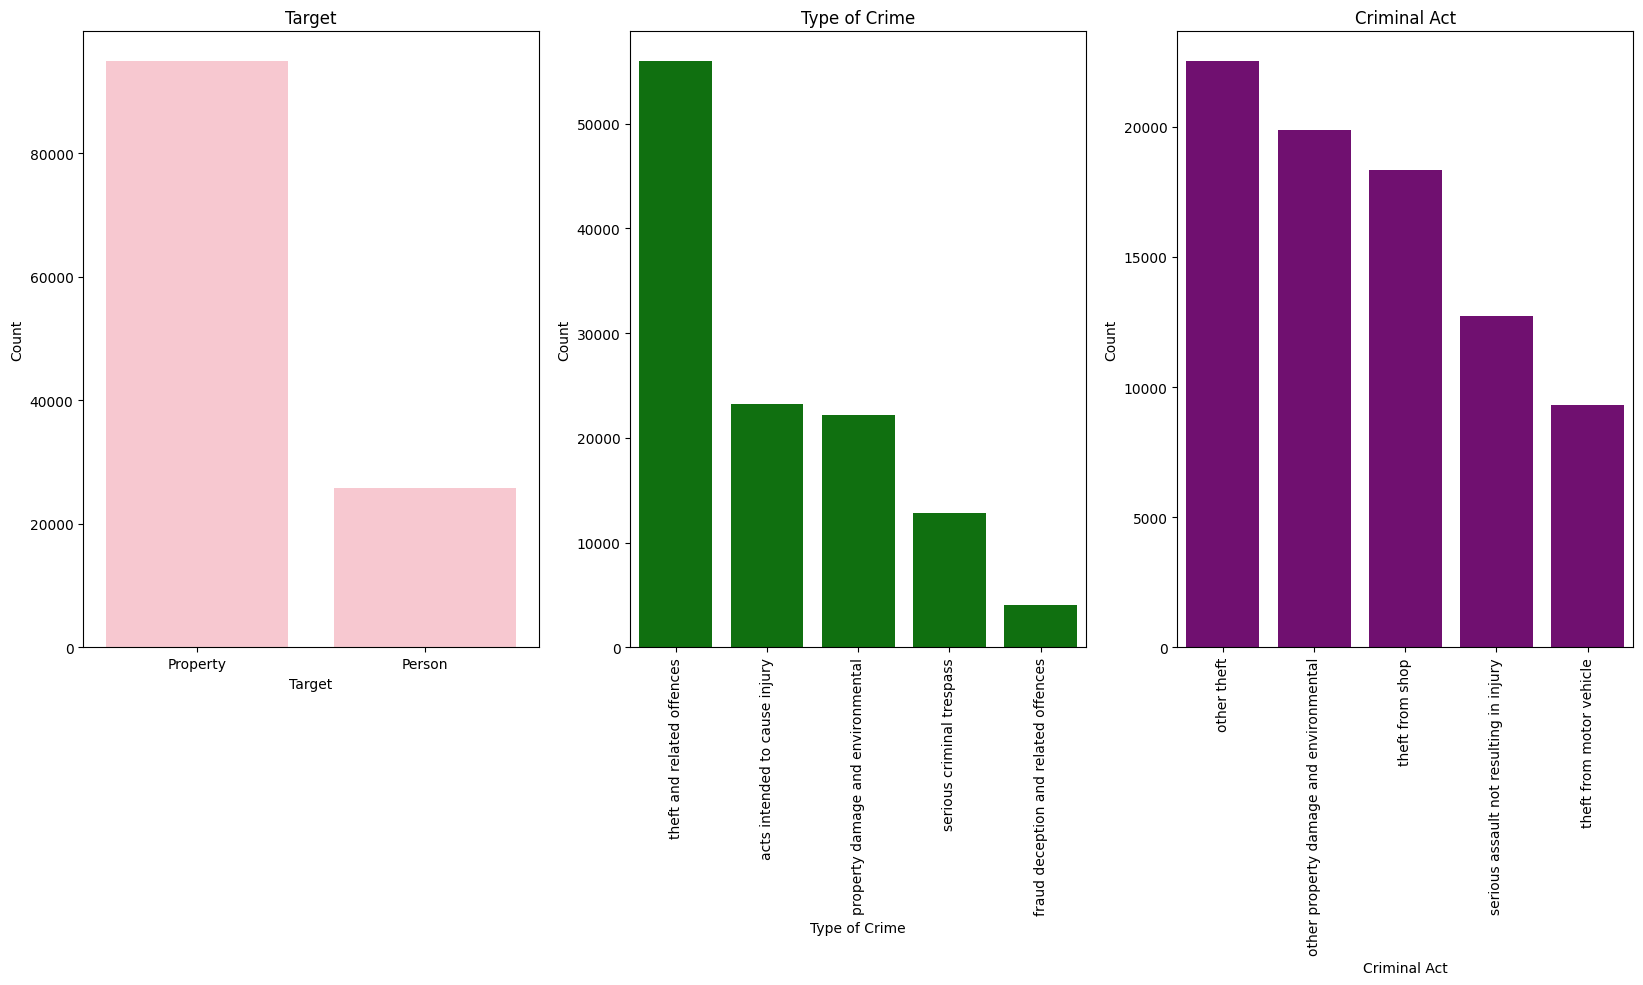

In [ ]:
#Graphs: barplots for Target, Type of Crime and Criminal Act
fig, axes = plt.subplots(1,3, figsize=(20,8))

sns.barplot(data = df_pivot_target, x = 'Target', y = 'Offence count', color = 'pink', ax=axes[0])
axes[0].set_title('Target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')

sns.barplot(data = df_pivot_type, x = 'Type of Crime', y = 'Offence count', color = 'green', ax=axes[1])
axes[1].set_title('Type of Crime')
axes[1].set_xlabel('Type of Crime')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

sns.barplot(data = df_pivot_act, x = 'Criminal Act', y = 'Offence count', color = 'purple', ax=axes[2])
axes[2].set_title('Criminal Act')
axes[2].set_xlabel('Criminal Act')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis = 'x', rotation = 90)

plt.show()

In [ ]:
#converting to datetime and retaining only month and year
df['Month'] = pd.to_datetime(df['Month'], format = "mixed")
df = df.sort_values(by='Month')

In [ ]:
import datetime

df['Month'] = df['Month'].dt.strftime('%Y-%m')

In [ ]:
## Create pivot table for Quarter
df_pivot_quarter = df.pivot_table(index='Month', values = 'Offence count', aggfunc='sum')



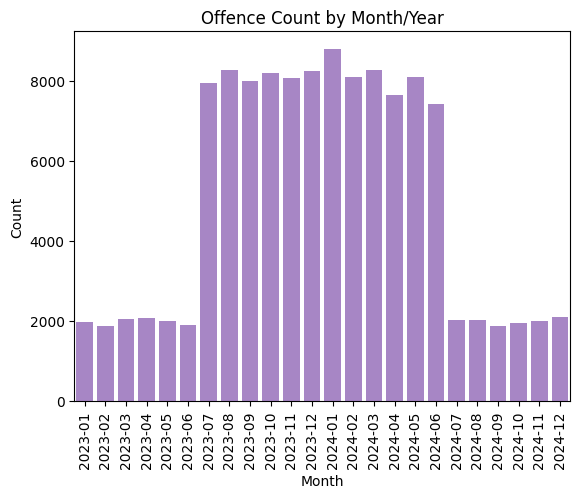

In [ ]:
#Graph: Barplot for Quarter
sns.barplot(data = df_pivot_quarter, x = 'Month', y = 'Offence count', color = '#A87CCF')
plt.title('Offence Count by Month/Year')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [ ]:
#Conversion of postcode to integer type
df['Postcode'] = df['Postcode'].astype(int)

In [ ]:
#new data frame for just the postcode and offence count
df_postcode_count = df[['Postcode', 'Offence count']]

In [ ]:
## Create pivot table for Postcode
df_postcode_count = df_postcode_count.pivot_table(index='Postcode', values = 'Offence count', aggfunc='sum')

In [ ]:
df_postcode_count

,Offence count
Postcode,
4104,1
4128,1
4304,1
5000,8563
5008,4967
...,...
5732,33
5736,4
5952,240


In [ ]:
#Import geopandas
import geopandas as gpd
df_postcode_count = df_postcode_count.reset_index()

In [ ]:
df_postcode_count

,Postcode,Offence count
0,4104,1
1,4128,1
2,4304,1
3,5000,8563
4,5008,4967
...,...,...
131,5732,33
132,5736,4
133,5952,240
134,5960,5


In [ ]:
df_postcode_count

,Postcode,Offence count
0,4104,1
1,4128,1
2,4304,1
3,5000,8563
4,5008,4967
...,...,...
131,5732,33
132,5736,4
133,5952,240
134,5960,5


In [ ]:
df_postcode_count = df_postcode_count[(df_postcode_count['Postcode']>=5000) & (df_postcode_count['Postcode']<=5999)]

In [ ]:
#importing boundary data
boundary = gpd.read_file('POA_2021_AUST_GDA2020_SHP.zip')

In [ ]:
boundary = boundary.rename(columns={'POA_CODE21': 'Postcode'})

In [ ]:
#removing dummy data from boundary file
boundary = boundary[~boundary['Postcode'].isin(['ZZZZ'])]

In [ ]:
boundary['Postcode'].value_counts()

,count
Postcode,
9797,1
0800,1
0810,1
7307,1
7306,1
...,...
0830,1
0829,1
0828,1


In [ ]:
#converting postcode in boundary data to integer to merge with postcode column in pivot table for postcode and offence count.
boundary['Postcode'] = boundary['Postcode'].astype(int)

In [ ]:
#merging of pivot table and boundary data
postcode_count__boundary = boundary.merge(df_postcode_count, on='Postcode', how = 'inner')

In [ ]:
postcode_count__boundary

,Postcode,POA_NAME21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,SHAPE_Leng,SHAPE_Area,geometry,Offence count
0,5000,5000,AUS,Australia,10.4824,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.162606,0.001034,"POLYGON ((138.60676 -34.94098, 138.60521 -34.9...",8563
1,5008,5008,AUS,Australia,6.1854,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.114372,0.000610,"POLYGON ((138.57956 -34.8941, 138.5784 -34.893...",4967
2,5012,5012,AUS,Australia,4.3752,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.093633,0.000431,"POLYGON ((138.55451 -34.87207, 138.55199 -34.8...",3433
3,5016,5016,AUS,Australia,4.8979,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.096265,0.000483,"POLYGON ((138.49484 -34.83377, 138.49477 -34.8...",3260
4,5020,5020,AUS,Australia,1.5622,http://linked.data.gov.au/dataset/asgsed3/POA/...,0.070685,0.000154,"POLYGON ((138.49427 -34.85777, 138.49439 -34.8...",1770
...,...,...,...,...,...,...,...,...,...,...
84,5680,5680,AUS,Australia,6743.6481,http://linked.data.gov.au/dataset/asgsed3/POA/...,9.073350,0.646492,"MULTIPOLYGON (((134.19195 -33.01457, 134.19226...",67
85,5700,5700,AUS,Australia,1098.2879,http://linked.data.gov.au/dataset/asgsed3/POA/...,3.183313,0.105502,"MULTIPOLYGON (((137.76713 -32.47106, 137.76678...",3544
86,5720,5720,AUS,Australia,28341.6471,http://linked.data.gov.au/dataset/asgsed3/POA/...,16.983334,2.658354,"MULTIPOLYGON (((136.5854 -31.19838, 136.57401 ...",52
87,5724,5724,AUS,Australia,39211.1945,http://linked.data.gov.au/dataset/asgsed3/POA/...,10.938266,3.561926,"POLYGON ((133.8354 -28.07494, 133.35877 -28.06...",913


/tmp/ipython-input-3830864109.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 2000x2000 with 0 Axes>

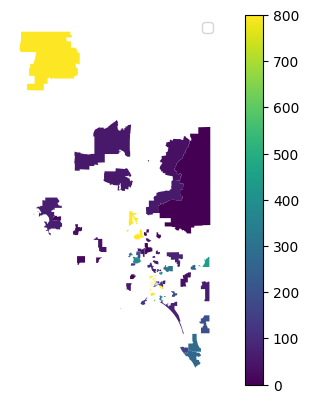

In [ ]:
#Graph: map of Adeliade with fill being the offence count
plt.figure(figsize=(20,20))
postcode_count__boundary.plot(column = 'Offence count', legend = True, vmin = 0, vmax = 800)
plt.axis('off')
plt.legend()
plt.show()

#2022 to 2023


In [ ]:
df_ = pd.read_csv('2022-23_data_sa_crime.csv')

#target, type of crime, criminal act

In [ ]:
#renaming columns

df_ = df_.rename(columns={'Reported Date': 'Month', 'Suburb - Incident': 'Suburb', 'Postcode - Incident': 'Postcode',
                         'Offence Level 1 Description':'Target', 'Offence Level 2 Description':'Type of Crime', 'Offence Level 3 Description':'Criminal Act'})

In [ ]:
#checking updated column names
df_.columns

Index(['Month', 'Suburb', 'Postcode', 'Target', 'Type of Crime',
       'Criminal Act', 'Offence count'],
      dtype='object')

In [ ]:
#converting to date time structure
df_['Month'] = pd.to_datetime(df_['Month'], format = "mixed")

In [ ]:
df_['Month'] = df_['Month'].dt.strftime('%Y-%m')

In [ ]:
df_ = df_.sort_values(by='Month')

In [ ]:
df_

,Month,Suburb,Postcode,Target,Type of Crime,Criminal Act,Offence count
0,2022-01,ADELAIDE,5000,OFFENCES AGAINST PROPERTY,FRAUD DECEPTION AND RELATED OFFENCES,"Other fraud, deception and related offences",1
31323,2022-01,PARA HILLS WEST,5096,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Other theft,1
31324,2022-01,PARA HILLS WEST,5096,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Theft from motor vehicle,1
31325,2022-01,PARA HILLS WEST,5096,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Theft from shop,1
31326,2022-01,PARA VISTA,5093,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Theft from motor vehicle,2
...,...,...,...,...,...,...,...
59368,2023-12,GRANGE,5022,OFFENCES AGAINST PROPERTY,PROPERTY DAMAGE AND ENVIRONMENTAL,Other property damage and environmental,1
59369,2023-12,GRANGE,5022,OFFENCES AGAINST PROPERTY,THEFT AND RELATED OFFENCES,Theft from motor vehicle,1
59370,2023-12,GRANGE,5022,OFFENCES AGAINST THE PERSON,ACTS INTENDED TO CAUSE INJURY,Serious Assault resulting in injury,1
59372,2023-12,GREENWITH,5125,OFFENCES AGAINST PROPERTY,PROPERTY DAMAGE AND ENVIRONMENTAL,Other property damage and environmental,1


In [ ]:
#replacing values in column
df_['Target'] = df_['Target'].str.replace('OFFENCES AGAINST THE PERSON', 'Person')
df_['Target'] = df_['Target'].str.replace('OFFENCES AGAINST PROPERTY', 'Property')

In [ ]:
#converting to lower case
df_['Type of Crime'] = df_['Type of Crime'].str.lower()
df_['Criminal Act'] = df_['Criminal Act'].str.lower()

In [ ]:
#creating pivot tables
##target
df__pivot_target = df_.pivot_table(index='Target', values = 'Offence count', aggfunc='sum')
df__pivot_target = df__pivot_target.sort_values(by='Offence count', ascending=False)

##type of crime
df__pivot_type = df_.pivot_table(index='Type of Crime', values = 'Offence count', aggfunc='sum')
df__pivot_type = df__pivot_type.sort_values(by='Offence count', ascending=False)
df__pivot_type = df__pivot_type.iloc[0:5,]

##criminal act
df__pivot_act = df_.pivot_table(index='Criminal Act', values = 'Offence count', aggfunc='sum')
df__pivot_act = df__pivot_act.sort_values(by='Offence count', ascending=False)
df__pivot_act = df__pivot_act.iloc[0:5,]

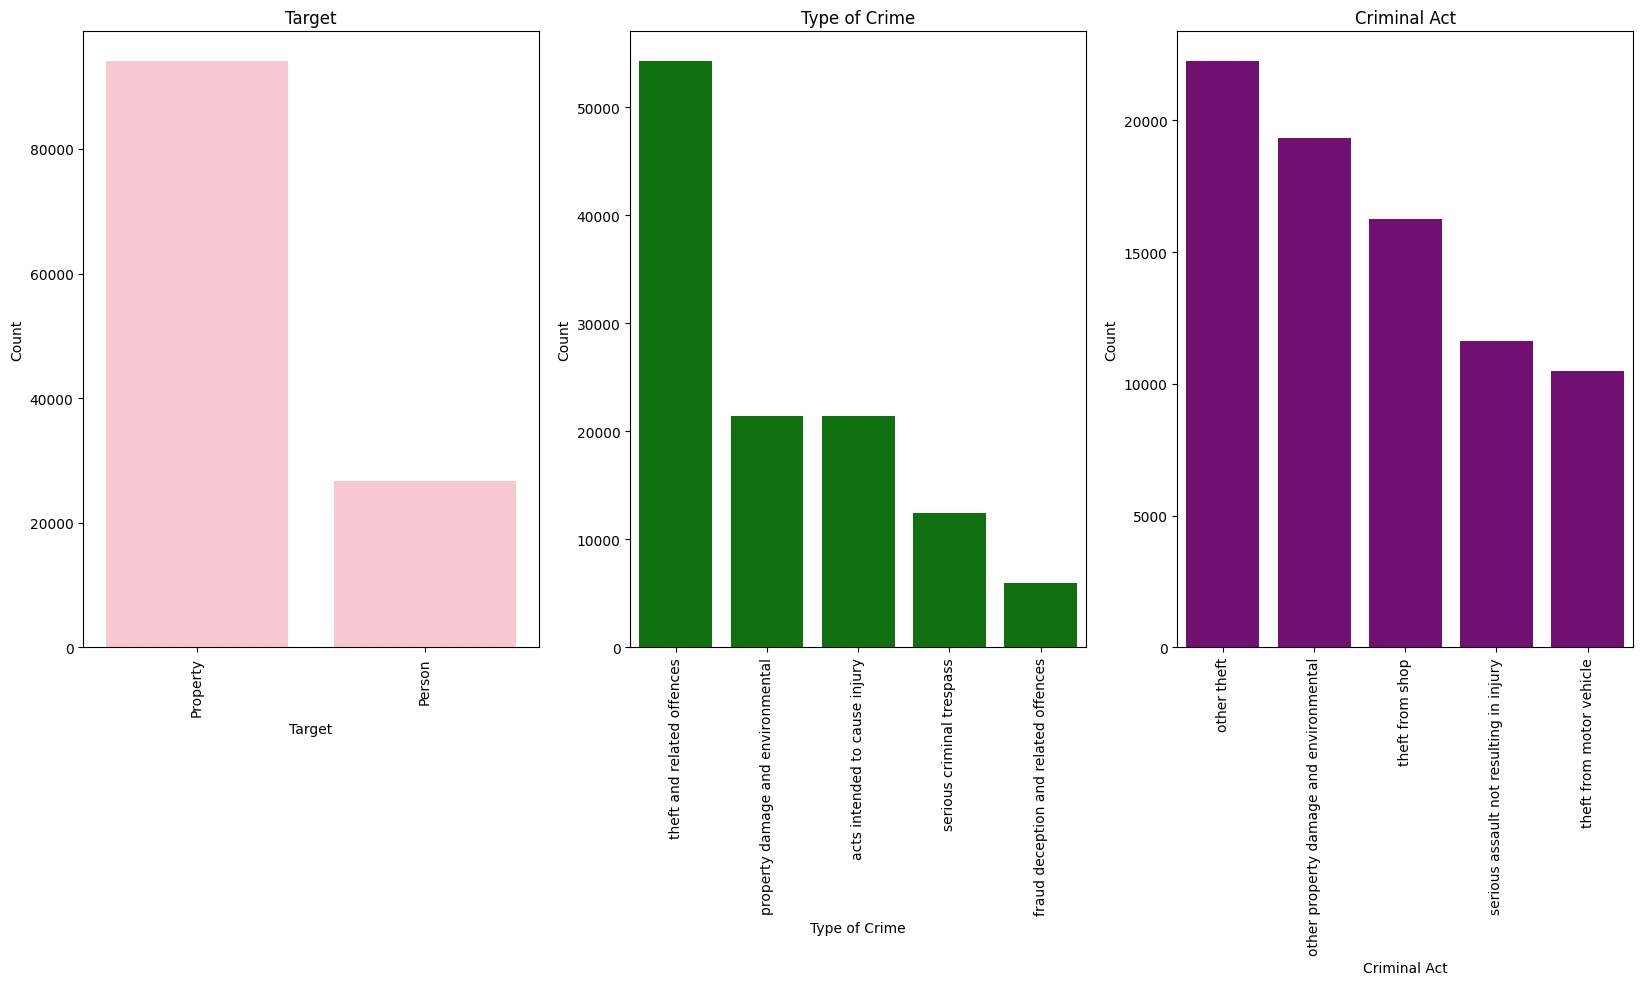

In [ ]:
fig, axes  = plt.subplots(1,3, figsize = (20,8))

sns.barplot(x ='Target', y = 'Offence count', data = df__pivot_target, color = 'pink', ax = axes[0])
axes[0].set_title('Target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis = 'x', rotation = 90)

sns.barplot(x = 'Type of Crime', y = 'Offence count', data = df__pivot_type, color = 'green', ax = axes[1])
axes[1].set_title('Type of Crime')
axes[1].set_xlabel('Type of Crime')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation = 90)

sns.barplot(x = 'Criminal Act', y = 'Offence count', data = df__pivot_act, color = 'purple', ax = axes[2])
axes[2].set_title('Criminal Act')
axes[2].set_xlabel('Criminal Act')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis = 'x', rotation = 90)

plt.show()

In [ ]:
#offence count by month
df__pivot_month = df_.pivot_table(index='Month', values = 'Offence count', aggfunc = 'sum')


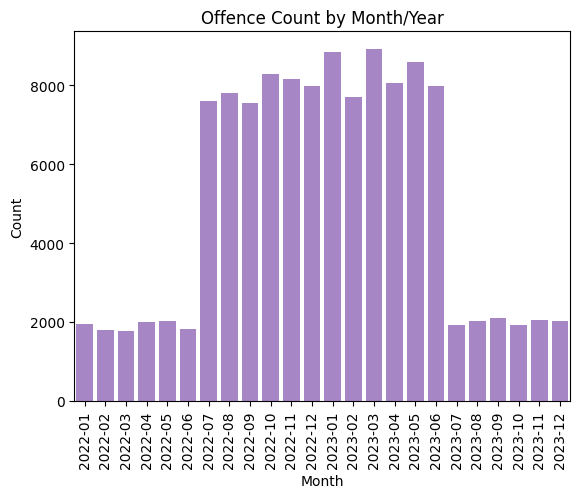

In [ ]:
#graphical depiction
sns.barplot(data = df__pivot_month, x = 'Month', y = 'Offence count', color = '#A87CCF')
plt.title('Offence Count by Month/Year')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

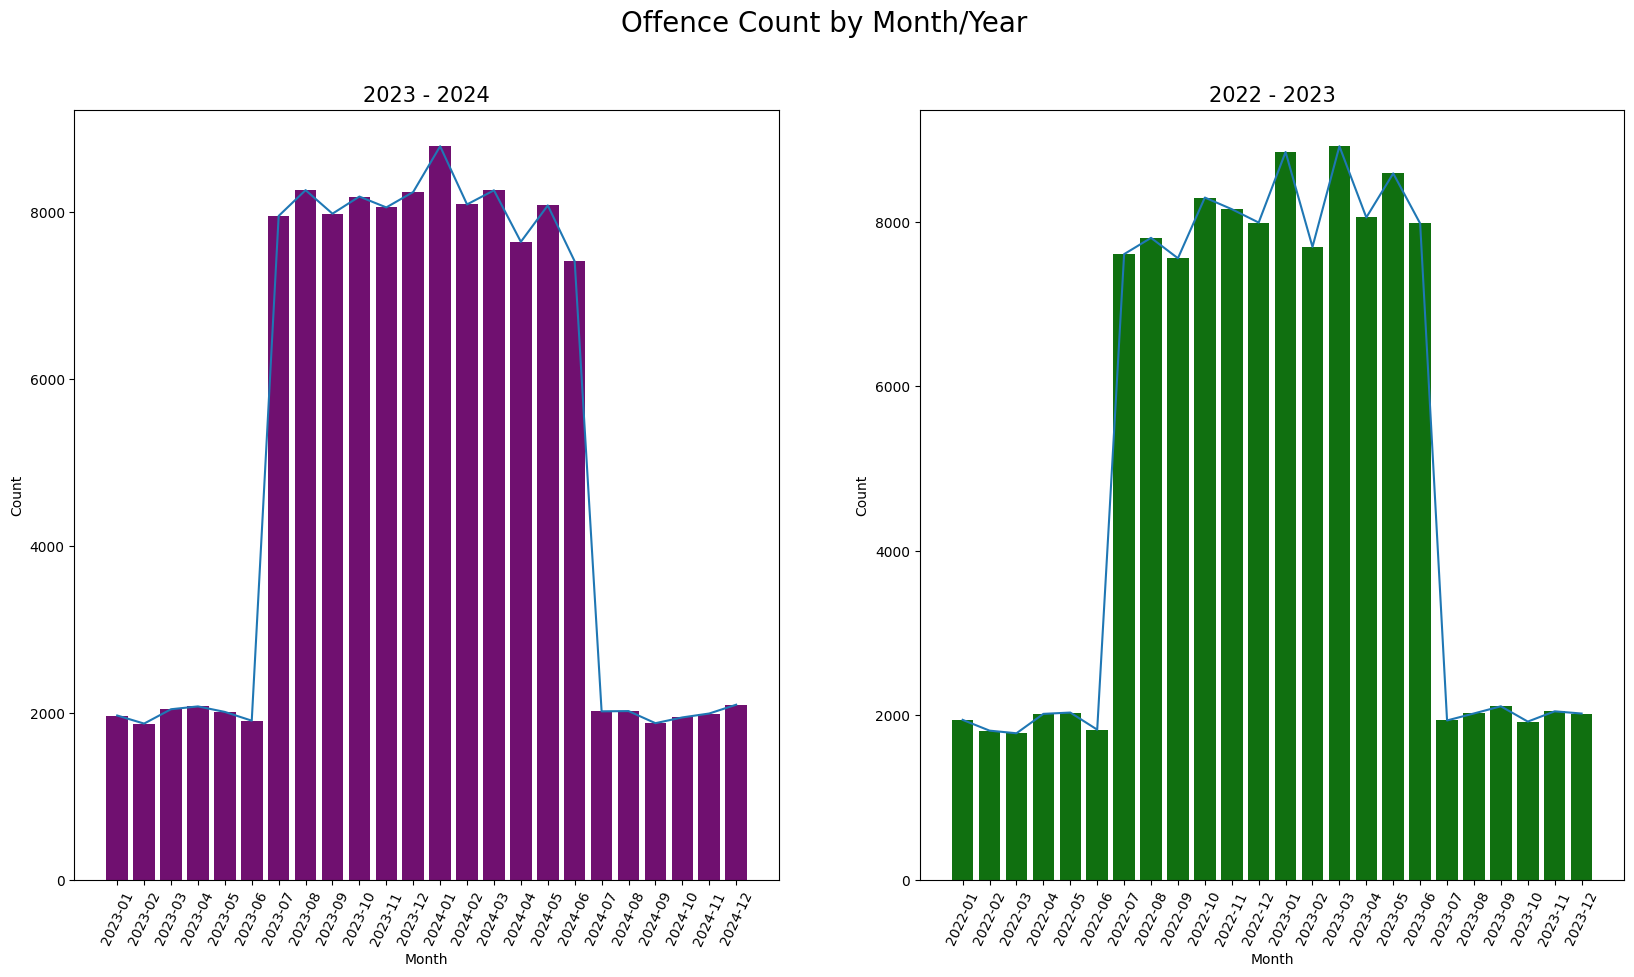

In [ ]:
fig, axes = plt.subplots (1,2, figsize = (20,10))
fig.suptitle('Offence Count by Month/Year', size = 20)

sns.barplot(data = df_pivot_quarter, x = 'Month', y = 'Offence count', color = 'purple', ax = axes[0])
sns.lineplot(data= df_pivot_quarter, color = 'purple',ax = axes[0], legend = False)
axes[0].set_title('2023 - 2024', fontsize = 15)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis = 'x', rotation = 65)

sns.barplot(data = df__pivot_month, x = 'Month', y = 'Offence count', color = 'green', ax = axes[1])
sns.lineplot(data= df__pivot_month, ax = axes[1], color = '#000000', legend = False)
axes[1].set_title('2022 - 2023', fontsize = 15)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis = 'x', rotation = 65)

In [ ]:
##Create pivot table for postcodes
df__pivot_postcode = df_.pivot_table(index='Postcode', values = 'Offence count', aggfunc='sum')

In [ ]:
df__pivot_postcode = df__pivot_postcode.reset_index()

In [ ]:
df__pivot_postcode

,Postcode,Offence count
0,2062,1
1,2250,1
2,2262,2
3,2316,1
4,2560,1
...,...,...
374,6073,1
375,6306,1
376,6503,1
377,872,645


In [ ]:
df__pivot_postcode = df__pivot_postcode[~df__pivot_postcode['Postcode'].isin(['NOT DISCLOSED'])]


In [ ]:
df__pivot_postcode['Postcode'] = df__pivot_postcode['Postcode'].astype('int')

/tmp/ipython-input-2601777015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df__pivot_postcode['Postcode'] = df__pivot_postcode['Postcode'].astype('int')


In [ ]:
df__pivot_postcode = df__pivot_postcode[(df__pivot_postcode['Postcode']>=5000) & (df__pivot_postcode['Postcode']<=5999)]

In [ ]:
df__pivot_postcode['Postcode'].value_counts()

,count
Postcode,
5960,1
5000,1
5006,1
5007,1
5713,1
...,...
5013,1
5012,1
5011,1


In [ ]:
#joining to boundary

df__pivot_postcode = df__pivot_postcode.reset_index(drop = True)

boundary_postcode = boundary.merge(df__pivot_postcode, on='Postcode', how = 'inner')

/tmp/ipython-input-2125056301.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 2000x2000 with 0 Axes>

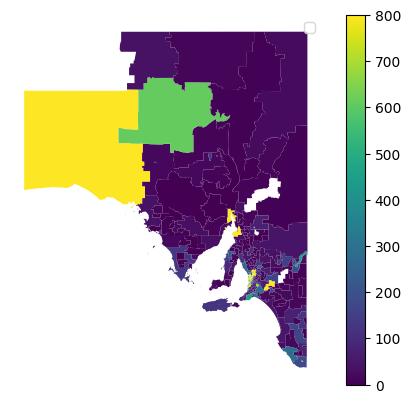

In [ ]:
#Graph: map of Adeliade with fill being the offence count
plt.figure(figsize=(20,20))
boundary_postcode.plot(column = 'Offence count', legend = True, vmin = 0, vmax = 800)
plt.axis('off')
plt.legend()
plt.show()